# Kotva Insurance Portfolio Analysis

**Objective:** turn the anonymized ETL export into decision-ready findings for sales, collection, and claims teams.

This notebook demonstrates a typical analyst workflow: validate the input, define metrics, explore trends and segments, visualize results, and translate evidence into business recommendations. Monetary values are analyzed separately by currency.

## Business questions

1. How much premium was written and collected, and what remains outstanding?
2. Is policy sales activity seasonal and how does it change year over year?
3. Which insurers lead on premium, collection rate, and estimated loss ratio?
4. Which insurance and age segments show the greatest payment or claim risk?
5. What actions should commercial and operations teams prioritize?

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
pd.options.display.float_format = lambda value: f"{value:,.2f}"
KOTVA_COLORS = ["#102d46", "#e76f51", "#39a88e", "#f2b84b", "#7b6ee6"]

In [2]:
default_path = Path("analytics/data/sample_analytics_dataset.csv")
if not default_path.exists():
    default_path = Path("data/sample_analytics_dataset.csv")
dataset_path = Path(os.getenv("KOTVA_DATASET", default_path))
df = pd.read_csv(dataset_path, encoding="utf-8-sig", parse_dates=["sale_date", "valid_from", "valid_until"])
print(f"Loaded {len(df):,} policies from {dataset_path}")
display(df.head(3))

Loaded 36 policies from data\sample_analytics_dataset.csv


,policy_number,customer_id,customer_age,customer_age_group,insurance_type,insurer,sale_date,sale_year,sale_month,sale_quarter,...,policy_duration_days,premium,currency,amount_paid,remaining_amount,policy_status,payment_status,claim_count,open_claim_count,total_estimated_claim_value
0,POL-2025-001,CUST-00A1,29,26-35,Putno,Uniqa,2025-01-12,2025,1,Q1,...,365,4200,RSD,4200,0,Istekla,Plaćeno,0,0,0
1,POL-2025-002,CUST-00A2,44,36-45,Auto,Generali,2025-01-25,2025,1,Q1,...,365,28500,RSD,28500,0,Istekla,Plaćeno,1,0,9000
2,POL-2025-003,CUST-00A3,34,26-35,Putno,Sava,2025-02-08,2025,2,Q1,...,365,3900,RSD,3900,0,Istekla,Plaćeno,0,0,0


## 1. Validate and prepare the dataset

Failing early on schema or key problems prevents polished charts from hiding unreliable data. Direct personal identifiers are explicitly prohibited.

In [3]:
required_columns = {
    "policy_number", "customer_id", "customer_age", "customer_age_group",
    "insurance_type", "insurer", "sale_date", "sale_year", "sale_month",
    "premium", "currency", "amount_paid", "remaining_amount",
    "policy_status", "payment_status", "claim_count",
    "open_claim_count", "total_estimated_claim_value"
}
forbidden_columns = {"name", "surname", "jmbg", "passport_number", "client_name"}
missing_columns = required_columns - set(df.columns)
assert not missing_columns, f"Missing required columns: {sorted(missing_columns)}"
assert forbidden_columns.isdisjoint(df.columns), "Direct identifiers found in analytical data"
assert df["policy_number"].is_unique, "Policy number must be unique"
assert df["customer_id"].str.match(r"^CUST-[A-Z0-9]+$").all(), "Customer IDs are not pseudonymous"
numeric_columns = ["customer_age", "premium", "amount_paid", "remaining_amount", "claim_count", "open_claim_count", "total_estimated_claim_value"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
df["collection_rate"] = np.where(df["premium"] > 0, df["amount_paid"] / df["premium"], np.nan)
df["estimated_loss_ratio"] = np.where(df["premium"] > 0, df["total_estimated_claim_value"] / df["premium"], np.nan)
df["sale_period"] = df["sale_date"].dt.to_period("M")
quality_summary = pd.DataFrame({
    "metric": ["Rows", "Columns", "Missing cells", "Duplicate policies", "Currencies"],
    "value": [len(df), len(df.columns), int(df.isna().sum().sum()), int(df["policy_number"].duplicated().sum()), ", ".join(sorted(df["currency"].unique()))],
})
display(quality_summary)

,metric,value
0,Rows,36
1,Columns,25
2,Missing cells,0
3,Duplicate policies,0
4,Currencies,"EUR, RSD"


## 2. Executive KPIs by currency

The selected currency can also be supplied with `KOTVA_CURRENCY`. Cross-currency sums are intentionally avoided. Estimated loss ratio is a portfolio proxy, not an accounting incurred-loss ratio.

In [4]:
currency = os.getenv("KOTVA_CURRENCY", "RSD")
assert currency in set(df["currency"]), f"Choose one of {sorted(df['currency'].unique())}"
portfolio = df.loc[df["currency"] == currency].copy()
written = portfolio["premium"].sum()
collected = portfolio["amount_paid"].sum()
claims = portfolio["total_estimated_claim_value"].sum()
kpis = pd.Series({
    "Policies": len(portfolio),
    f"Written premium ({currency})": written,
    f"Collected premium ({currency})": collected,
    f"Outstanding premium ({currency})": portfolio["remaining_amount"].sum(),
    "Collection rate": collected / written if written else np.nan,
    "Claim frequency": (portfolio["claim_count"] > 0).mean(),
    "Estimated loss ratio": claims / written if written else np.nan,
    f"Average premium ({currency})": portfolio["premium"].mean(),
})
display(kpis.to_frame("value"))

,value
Policies,32.00
Written premium (RSD),"408,500.00"
Collected premium (RSD),"310,155.00"
Outstanding premium (RSD),"98,345.00"
Collection rate,0.76
Claim frequency,0.34
Estimated loss ratio,0.69
Average premium (RSD),"12,765.62"


## 3. Monthly sales and year-over-year trend

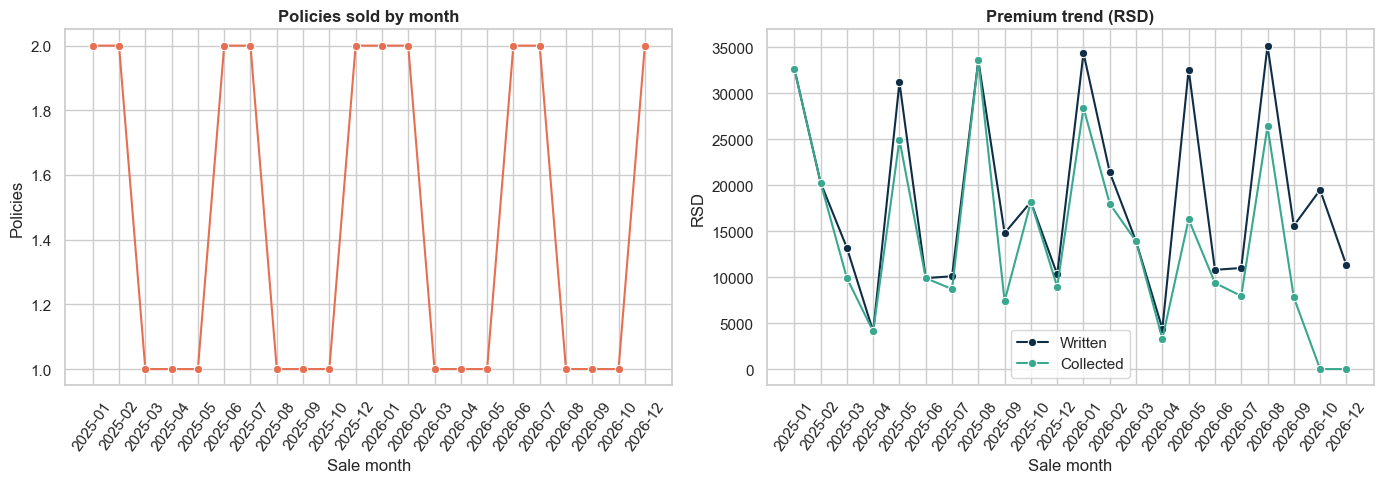

sale_year,2025,2026
month,,
1,2,2
2,2,2
3,1,1
4,1,1
5,1,1
6,2,2
7,2,2
8,1,1
9,1,1


In [5]:
monthly = portfolio.groupby("sale_period").agg(policies=("policy_number", "count"), written_premium=("premium", "sum"), collected_premium=("amount_paid", "sum")).reset_index()
monthly["sale_month"] = monthly["sale_period"].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=monthly, x="sale_month", y="policies", marker="o", color=KOTVA_COLORS[1], ax=axes[0])
axes[0].set(title="Policies sold by month", xlabel="Sale month", ylabel="Policies")
sns.lineplot(data=monthly, x="sale_month", y="written_premium", marker="o", label="Written", color=KOTVA_COLORS[0], ax=axes[1])
sns.lineplot(data=monthly, x="sale_month", y="collected_premium", marker="o", label="Collected", color=KOTVA_COLORS[2], ax=axes[1])
axes[1].set(title=f"Premium trend ({currency})", xlabel="Sale month", ylabel=currency)
for axis in axes: axis.tick_params(axis="x", rotation=55)
plt.tight_layout(); plt.show()
yoy = portfolio.pivot_table(index="sale_month", columns="sale_year", values="policy_number", aggfunc="count", fill_value=0)
display(yoy.rename_axis("month"))

## 4. Insurer performance benchmark

,insurer,policies,written_premium,collected_premium,estimated_claims,claimed_policies,collection_rate,estimated_loss_ratio,claim_frequency
3,Uniqa,10,124800,107300,50000,2,0.86,0.40,0.20
2,Sava,8,119100,77060,109000,3,0.65,0.92,0.38
0,Generali,8,89800,71040,21500,2,0.79,0.24,0.25
1,Milenijum,6,74800,54755,100900,4,0.73,1.35,0.67


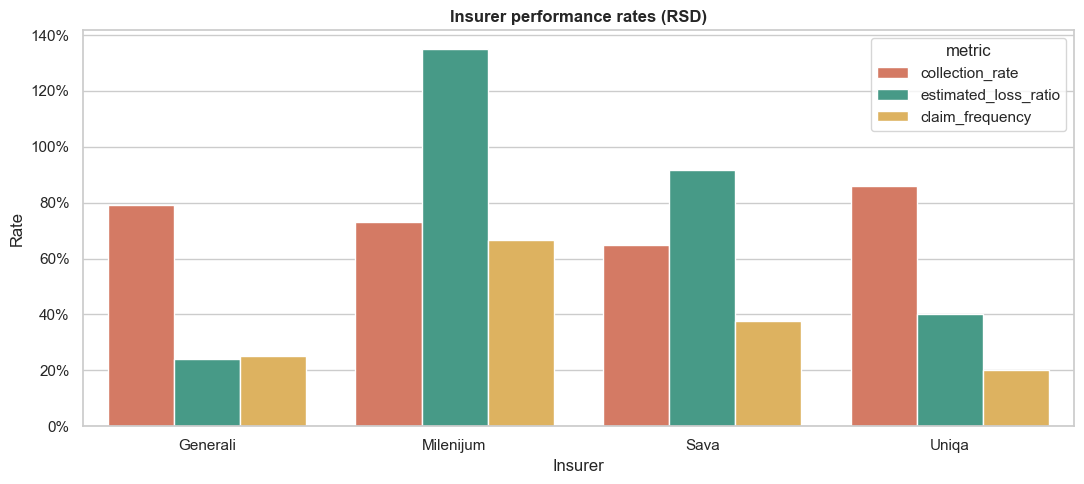

In [6]:
insurer = portfolio.groupby("insurer").agg(policies=("policy_number", "count"), written_premium=("premium", "sum"), collected_premium=("amount_paid", "sum"), estimated_claims=("total_estimated_claim_value", "sum"), claimed_policies=("claim_count", lambda values: (values > 0).sum())).reset_index()
insurer["collection_rate"] = insurer["collected_premium"] / insurer["written_premium"]
insurer["estimated_loss_ratio"] = insurer["estimated_claims"] / insurer["written_premium"]
insurer["claim_frequency"] = insurer["claimed_policies"] / insurer["policies"]
display(insurer.sort_values("written_premium", ascending=False))
plot_data = insurer.melt(id_vars="insurer", value_vars=["collection_rate", "estimated_loss_ratio", "claim_frequency"], var_name="metric", value_name="rate")
ax = sns.barplot(data=plot_data, x="insurer", y="rate", hue="metric", palette=KOTVA_COLORS[1:4])
ax.set(title=f"Insurer performance rates ({currency})", xlabel="Insurer", ylabel="Rate")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout(); plt.show()

## 5. Product and customer segmentation

,policies,average_premium,collection_rate,claim_frequency,estimated_loss_ratio
insurance_type,,,,,
Putno,18,"4,938.89",0.81,0.11,0.04
Auto,6,"31,816.67",0.81,1.00,0.58
DZO,4,"14,375.00",0.69,0.00,0.00
Privatna svojina,4,"17,800.00",0.70,0.75,2.37


,policies,average_premium,outstanding_premium,collection_rate
customer_age_group,,,,
18-25,3,"4,833.33",0,1.00
26-35,10,"4,610.00",7900,0.85
36-45,11,"13,100.00",36185,0.69
46-55,7,"26,328.57",34760,0.84
56-65,1,"19,500.00",19500,0.00


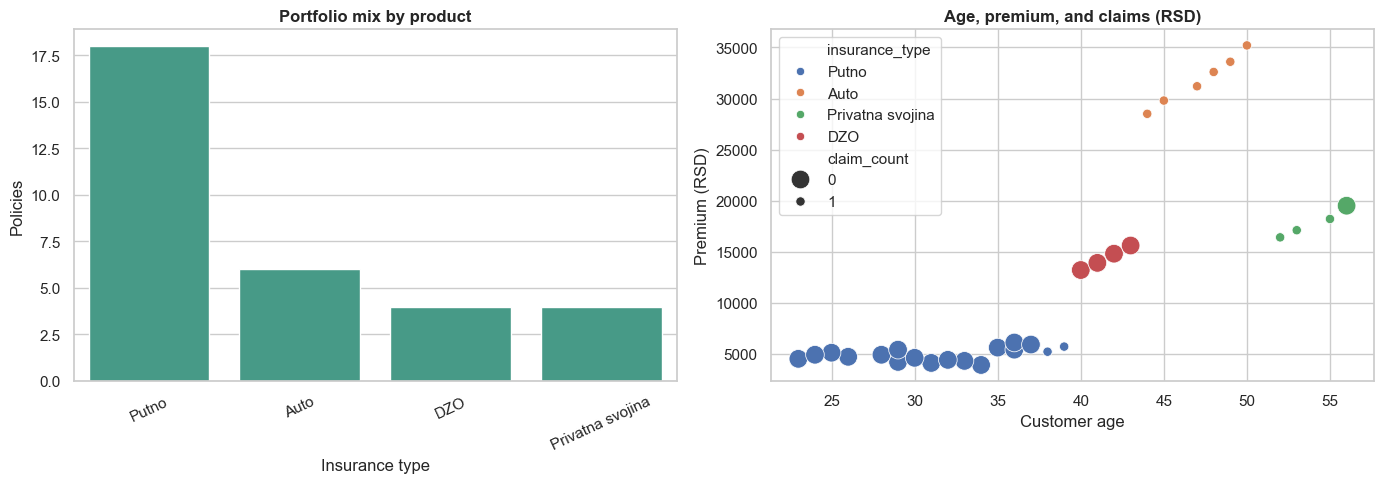

Pearson correlation between age and premium: 0.767


In [7]:
product = portfolio.groupby("insurance_type").agg(policies=("policy_number", "count"), average_premium=("premium", "mean"), collection_rate=("collection_rate", "mean"), claim_frequency=("claim_count", lambda values: (values > 0).mean()), estimated_loss_ratio=("estimated_loss_ratio", "mean")).sort_values("policies", ascending=False)
age_segment = portfolio.groupby("customer_age_group", observed=True).agg(policies=("policy_number", "count"), average_premium=("premium", "mean"), outstanding_premium=("remaining_amount", "sum"), collection_rate=("collection_rate", "mean")).sort_index()
display(product); display(age_segment)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=product.reset_index(), x="insurance_type", y="policies", color=KOTVA_COLORS[2], ax=axes[0])
axes[0].set(title="Portfolio mix by product", xlabel="Insurance type", ylabel="Policies"); axes[0].tick_params(axis="x", rotation=25)
sns.scatterplot(data=portfolio, x="customer_age", y="premium", hue="insurance_type", size="claim_count", sizes=(45, 180), ax=axes[1])
axes[1].set(title=f"Age, premium, and claims ({currency})", xlabel="Customer age", ylabel=f"Premium ({currency})")
plt.tight_layout(); plt.show()
print(f"Pearson correlation between age and premium: {portfolio['customer_age'].corr(portfolio['premium']):.3f}")

## 6. Payment-risk view

In [8]:
payment_risk = portfolio.pivot_table(index="insurance_type", columns="payment_status", values="remaining_amount", aggfunc="sum", fill_value=0)
payment_risk["total_outstanding"] = payment_risk.sum(axis=1)
display(payment_risk.sort_values("total_outstanding", ascending=False))
risk_rows = portfolio.loc[portfolio["remaining_amount"] > 0, ["policy_number", "customer_id", "insurance_type", "insurer", "premium", "remaining_amount", "payment_status"]].sort_values("remaining_amount", ascending=False)
display(risk_rows.head(10))

payment_status,Delimično plaćeno,Neplaćeno,Plaćeno,total_outstanding
insurance_type,,,,
Auto,37300,0,0,37300
Privatna svojina,3420,19500,0,22920
Putno,8325,11300,0,19625
DZO,18500,0,0,18500


,policy_number,customer_id,insurance_type,insurer,premium,remaining_amount,payment_status
29,POL-2026-014,CUST-00D4,Privatna svojina,Sava,19500,19500,Neplaćeno
22,POL-2026-007,CUST-00C7,Auto,Sava,32600,16300,Delimično plaćeno
27,POL-2026-012,CUST-00D2,Auto,Uniqa,35200,8800,Delimično plaćeno
28,POL-2026-013,CUST-00D3,DZO,Milenijum,15600,7800,Delimično plaćeno
12,POL-2025-013,CUST-00B3,DZO,Milenijum,14800,7400,Delimično plaćeno
6,POL-2025-007,CUST-00A7,Auto,Sava,31200,6240,Delimično plaćeno
17,POL-2026-002,CUST-00C2,Auto,Generali,29800,5960,Delimično plaćeno
31,POL-2026-016,CUST-00D6,Putno,Generali,5900,5900,Neplaćeno
30,POL-2026-015,CUST-00D5,Putno,Uniqa,5400,5400,Neplaćeno
19,POL-2026-004,CUST-00C4,Privatna svojina,Milenijum,17100,3420,Delimično plaćeno


## 7. Evidence-based recommendations

In [9]:
seasonality = portfolio.groupby("sale_month").agg(policies=("policy_number", "count")).reset_index()
peak = seasonality.loc[seasonality["policies"].idxmax()]
best_collection = insurer.loc[insurer["collection_rate"].idxmax()]
highest_loss = insurer.loc[insurer["estimated_loss_ratio"].idxmax()]
highest_debt = product.assign(outstanding=portfolio.groupby("insurance_type")["remaining_amount"].sum()).sort_values("outstanding", ascending=False).iloc[0]
recommendations = [
    f"Plan acquisition campaigns before calendar month {int(peak['sale_month'])}, the strongest recurring month with {int(peak['policies'])} policies.",
    f"Use {best_collection['insurer']} as the collection benchmark ({best_collection['collection_rate']:.1%}).",
    f"Review pricing and claims controls for {highest_loss['insurer']}, which has the highest estimated loss ratio ({highest_loss['estimated_loss_ratio']:.1%}).",
    f"Prioritize payment follow-up for {highest_debt.name}; its outstanding premium is {highest_debt['outstanding']:,.0f} {currency}.",
]
for number, recommendation in enumerate(recommendations, 1):
    print(f"{number}. {recommendation}")

1. Plan acquisition campaigns before calendar month 1, the strongest recurring month with 4 policies.
2. Use Uniqa as the collection benchmark (86.0%).
3. Review pricing and claims controls for Milenijum, which has the highest estimated loss ratio (134.9%).
4. Prioritize payment follow-up for Auto; its outstanding premium is 37,300 RSD.


## Limitations and next steps

- The sample is intentionally small and demonstrates workflow rather than statistical significance.
- Claim values are estimates; earned premium, reserves, settled losses, and IBNR are not available.
- No exchange-rate table is available, so currencies remain separate.
- Renewal and customer retention require a one-customer-to-many-policies model.
- Recommended next step: load the ETL export into a dimensional warehouse and connect Power BI to the star schema.